<a href="https://colab.research.google.com/github/khalida2025cse-sudo/FDS_Lab_Experiments/blob/main/Exp_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
  Student  Subject  Marks  Attendance  Study_Hours
0       A    Maths     85          90            5
1       B  Science     90          95            6
2       C    Maths     75          80            3
3       D  Science     80          85            4
4       E    Maths     95          98            7

Missing values:
Student        0
Subject        0
Marks          0
Attendance     0
Study_Hours    0
dtype: int64

Summary Statistics:
          Marks  Attendance  Study_Hours
count   6.00000     6.00000     6.000000
mean   85.50000    90.00000     5.000000
std     7.17635     6.60303     1.414214
min    75.00000    80.00000     3.000000
25%    81.25000    86.25000     4.250000
50%    86.50000    91.00000     5.000000
75%    89.50000    94.25000     5.750000
max    95.00000    98.00000     7.000000

Subject Summary:
   Subject  Marks  Attendance
0    Maths    255   89.333333
1  Science    258   90.666667


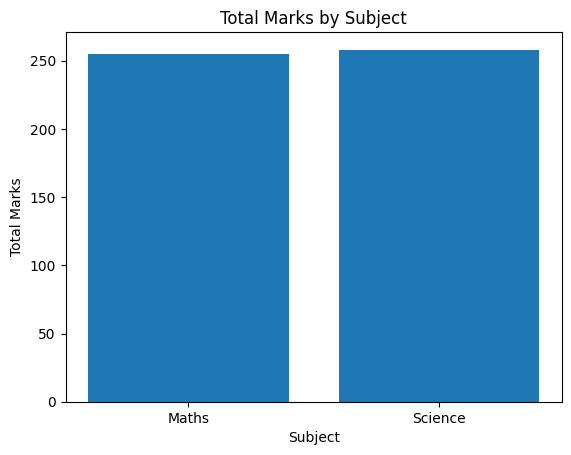

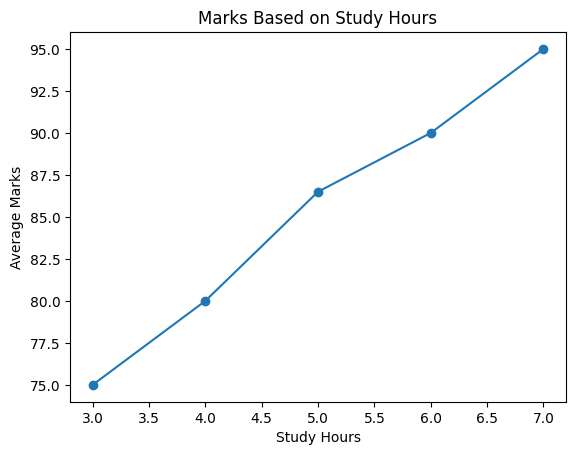


Pivot Table:
Study_Hours     3     4     5     6     7
Subject                                  
Maths        75.0   0.0  85.0   0.0  95.0
Science       0.0  80.0  88.0  90.0   0.0

Correlation Matrix:
                Marks  Attendance  Study_Hours
Marks        1.000000    0.996082     0.985329
Attendance   0.996082    1.000000     0.985212
Study_Hours  0.985329    0.985212     1.000000


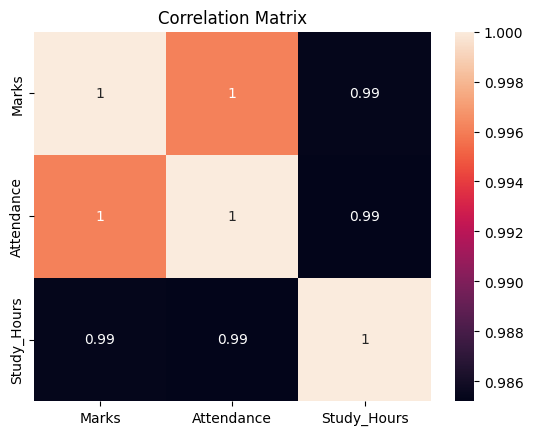

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Student': ['A','B','C','D','E','F'],
    'Subject': ['Maths','Science','Maths','Science','Maths','Science'],
    'Marks': [85,90,75,80,95,88],
    'Attendance': [90,95,80,85,98,92],
    'Study_Hours': [5,6,3,4,7,5]
}

df = pd.DataFrame(data)

print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

print("\nSummary Statistics:")
print(df.describe())

subject_summary = df.groupby('Subject').agg({
    'Marks': 'sum',
    'Attendance': 'mean'
}).reset_index()

print("\nSubject Summary:")
print(subject_summary)

plt.bar(subject_summary['Subject'], subject_summary['Marks'])
plt.xlabel('Subject')
plt.ylabel('Total Marks')
plt.title('Total Marks by Subject')
plt.show()

performance = df.groupby('Study_Hours')['Marks'].mean().reset_index()

plt.plot(performance['Study_Hours'], performance['Marks'], marker='o')
plt.xlabel('Study Hours')
plt.ylabel('Average Marks')
plt.title('Marks Based on Study Hours')
plt.show()

pivot_table = df.pivot_table(
    values='Marks',
    index='Subject',
    columns='Study_Hours',
    aggfunc='mean',
    fill_value=0
)

print("\nPivot Table:")
print(pivot_table)

correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()